# Singular Value Decomposition (SVD)

---

## Intuition

**SVD** factorizes *any* matrix into three interpretable components that reveal its underlying structure. Think of it as finding the "principal axes" of a data matrix without requiring it to be square or centered. The decomposition is unique (up to sign) and has deep connections to geometry: $U$ contains the directions in sample space, $V$ contains directions in feature space, and $\Sigma$ tells you how important each direction is.

SVD is the mathematical foundation of PCA, recommender systems (Netflix prize), image compression, and latent semantic analysis (LSA) in NLP.

---

## Factorization

For any matrix $A \in \mathbb{R}^{m \times n}$:

$$A = U \Sigma V^\top$$

where:
- $U \in \mathbb{R}^{m \times m}$: **left singular vectors** (orthonormal basis for the column space of $A$)
- $\Sigma \in \mathbb{R}^{m \times n}$: diagonal matrix of **singular values** $\sigma_1 \geq \sigma_2 \geq \cdots \geq 0$
- $V^\top \in \mathbb{R}^{n \times n}$: **right singular vectors** (orthonormal basis for the row space of $A$)

**Truncated SVD** keeps only the top $k$ components:

$$A_k = U_k \Sigma_k V_k^\top \quad (U_k \in \mathbb{R}^{m \times k},\; \Sigma_k \in \mathbb{R}^{k \times k},\; V_k^\top \in \mathbb{R}^{k \times n})$$

By the **Eckart-Young theorem**, $A_k$ is the best rank-$k$ approximation to $A$ in the Frobenius norm: $\min_{\text{rank}(B)=k} \|A - B\|_F = \|A - A_k\|_F$.

**Dimensionality reduction:** project data as $X_{\text{reduced}} = X \cdot V_k \in \mathbb{R}^{n \times k}$

**Explained variance ratio:** $\dfrac{\sigma_i^2}{\sum_j \sigma_j^2}$

---

## Advantages and Disadvantages

| | |
|---|---|
| **Advantages** | Works on any matrix (not just square); no centering required; mathematically optimal low-rank approximation; used in recommender systems |
| **Disadvantages** | Less interpretable than PCA; expensive for very large matrices; components are not sparse (hard to interpret) |

---

## SVD vs PCA

| Property | SVD | PCA |
|---|---|---|
| Requires centered data | No | Yes |
| Input | Raw matrix $X$ | Covariance matrix or centered $\tilde{X}$ |
| Key insight | PCA = SVD applied to **centered** $\tilde{X}$ | Eigendecomposition of covariance matrix |
| Output | Left/right singular vectors + singular values | Eigenvectors + eigenvalues |
| Relationship | $V$ from SVD of $\tilde{X}$ = eigenvectors of $\tilde{X}^\top \tilde{X}$ | Same |

---

## Summary Table

| Property | Value |
|---|---|
| Type | Matrix factorization / dimensionality reduction |
| Key parameters | $k$ (number of components to keep) |
| Optimality | Best rank-$k$ approximation (Eckart-Young) |
| Requires centering | No |
| Handles rectangular matrices | Yes |
| Applications | PCA, recommender systems, image compression, NLP (LSA) |

---

**Dataset:** Food Nutrition (`FOOD-DATA-GROUP1.csv`) or digits images  
**Task:** Low-rank approximation and dimensionality reduction.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme()

from rice_ml.unsupervised_learning import TruncatedSVD
from rice_ml.preprocess import StandardScaler

In [2]:
try:
    df = pd.read_csv('../../../data/FOOD-DATA-GROUP1.csv')
    num_cols = [c for c in df.select_dtypes(include=np.number).columns
               if 'unnamed' not in c.lower()]
    X = df[num_cols].fillna(0).values.astype(float)
    print(f'Loaded food nutrition dataset (FOOD-DATA-GROUP1): {X.shape}')
except FileNotFoundError:
    from sklearn.datasets import load_digits
    digits = load_digits()
    X = digits.data.astype(float)
    print(f'CSV not found. using digits dataset: {X.shape}')

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(f'Scaled shape: {X_scaled.shape}')

Loaded food nutrition dataset (FOOD-DATA-GROUP1): (551, 34)
Scaled shape: (551, 34)


## Dataset Description

**FOOD-DATA-GROUP1.csv** contains **551 food items** described by **37 nutritional features** (Caloric Value, Fat, Protein, Carbohydrates, Vitamins, Minerals).
[Download from Kaggle](https://www.kaggle.com/datasets/utsavdey1410/food-nutrition-dataset)


This is a **551 x 37 matrix**. SVD will decompose it into $U \Sigma V^\top$ and reveal the low-rank structure:
- The top singular vectors in $V$ represent the most important nutritional "directions"
- Foods with similar nutritional profiles will project similarly onto these directions
- The rapid decay of singular values will show how many components are truly needed

Unlike PCA, SVD does not require centering, though we still apply StandardScaler to ensure features are on a common scale.

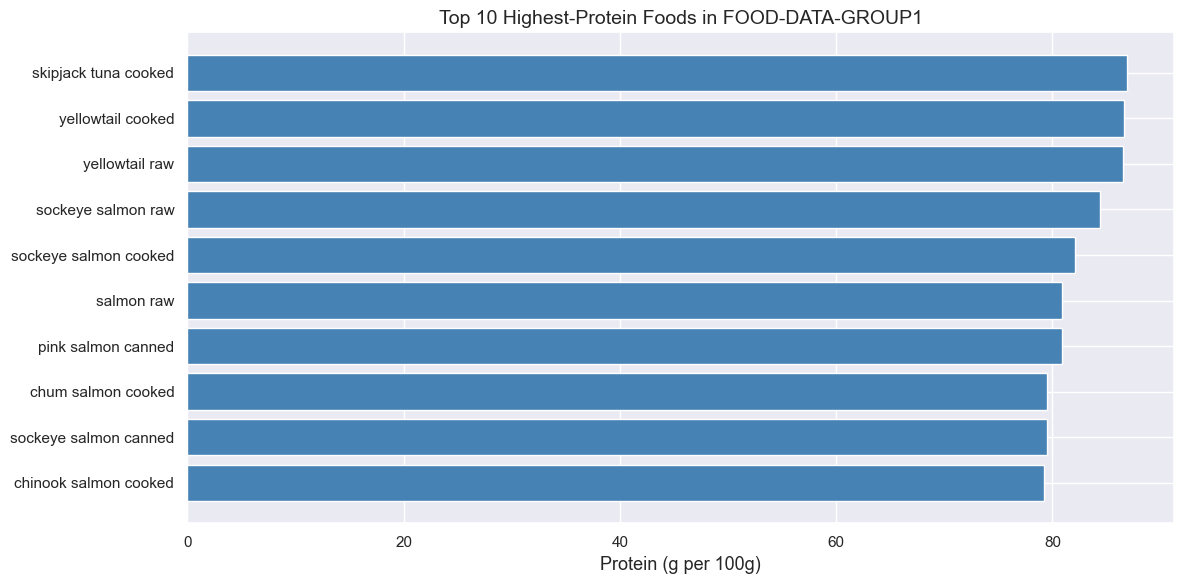

In [3]:
# --- EDA: Top 10 highest-protein foods ---
try:
    pro_col = [c for c in df.columns if 'protein' in c.lower()]
    name_col = [c for c in df.columns if df[c].dtype == object]
    if pro_col and name_col:
        top10_prot = df[[name_col[0], pro_col[0]]].dropna().nlargest(10, pro_col[0])
        fig, ax = plt.subplots(figsize=(12, 6))
        ax.barh(top10_prot[name_col[0]].str[:35], top10_prot[pro_col[0]], color='steelblue')
        ax.set_xlabel('Protein (g per 100g)', fontsize=13)
        ax.set_title('Top 10 Highest-Protein Foods in FOOD-DATA-GROUP1', fontsize=14)
        ax.invert_yaxis()
        plt.tight_layout()
        plt.show()
    else:
        print('Protein or name column not found; skipping.')
except NameError:
    print('Using digits data; skipping food bar chart.')

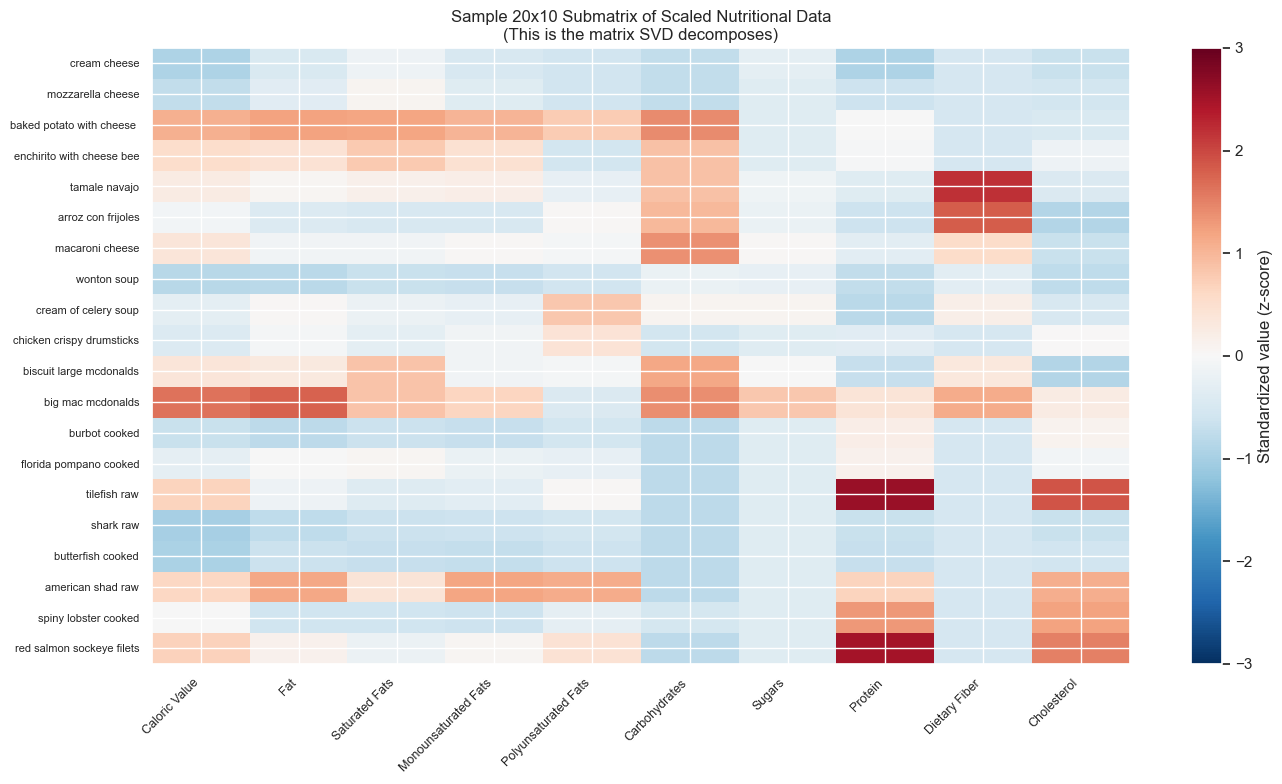

In [4]:
# --- EDA: Heatmap of a sample submatrix ---
# This visualizes the ACTUAL matrix that SVD will decompose.
# Each row is a food, each column is a nutritional feature.
n_foods_show = 20
n_feats_show = min(10, X_scaled.shape[1])

# Pick n_foods_show rows spread across the dataset
sample_rows = np.linspace(0, X_scaled.shape[0]-1, n_foods_show, dtype=int)
X_sub = X_scaled[sample_rows, :n_feats_show]

try:
    row_labels = df.iloc[sample_rows][name_col[0]].str[:25].tolist() if name_col else [f'Food {i}' for i in sample_rows]
    col_labels = num_cols[:n_feats_show]
except (NameError, IndexError):
    row_labels = [f'Sample {i}' for i in range(n_foods_show)]
    col_labels = [f'Feature {j}' for j in range(n_feats_show)]

fig, ax = plt.subplots(figsize=(14, 8))
im = ax.imshow(X_sub, cmap='RdBu_r', aspect='auto', vmin=-3, vmax=3)
plt.colorbar(im, ax=ax, label='Standardized value (z-score)')
ax.set_xticks(range(n_feats_show))
ax.set_xticklabels(col_labels, rotation=45, ha='right', fontsize=9)
ax.set_yticks(range(n_foods_show))
ax.set_yticklabels(row_labels, fontsize=8)
ax.set_title(f'Sample {n_foods_show}x{n_feats_show} Submatrix of Scaled Nutritional Data\n(This is the matrix SVD decomposes)', fontsize=12)
plt.tight_layout()
plt.show()

## SVD Matrix Factorization: Illustrated

The diagram below shows the shapes of the three matrices in the truncated SVD decomposition $A \approx U_k \Sigma_k V_k^\top$. For our food dataset with $m=551$ samples, $p=37$ features, and $k$ components:

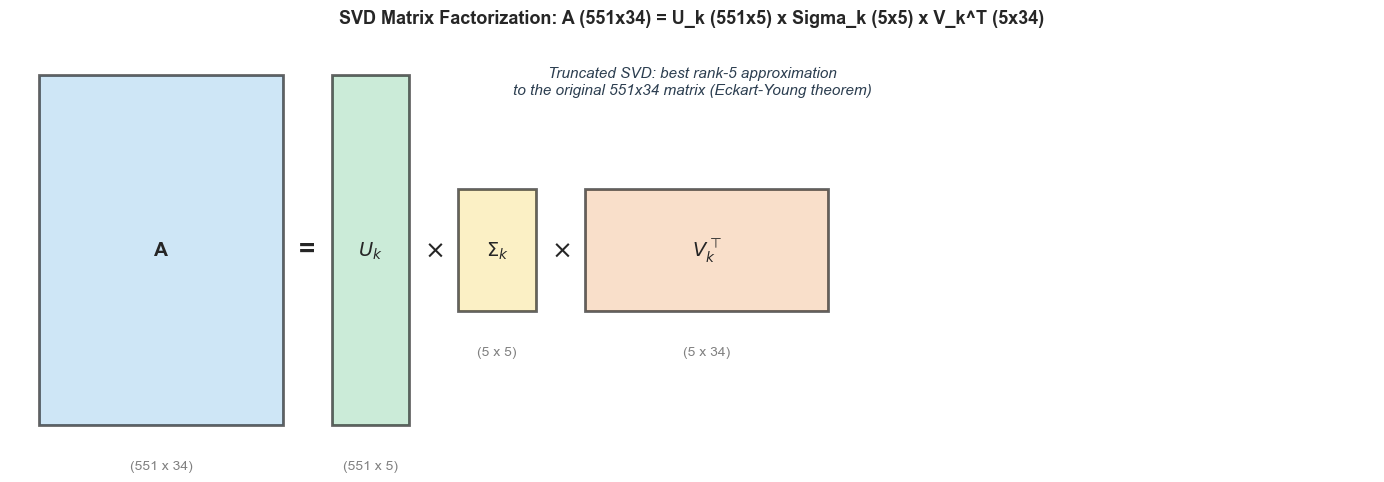

In [5]:
# --- Diagram: SVD matrix factorization as labeled rectangles ---
m, p = X_scaled.shape
k = 5  # example number of components

fig, ax = plt.subplots(figsize=(14, 5))
ax.set_xlim(0, 14)
ax.set_ylim(0, 5)
ax.axis('off')

# Scale for visual clarity
# A: m x p  -> show as tall wide rect
# U_k: m x k -> tall narrow
# Sigma_k: k x k -> small square
# V_k^T: k x p -> short wide

def draw_matrix(ax, x, y, w, h, label, shape_label, color):
    rect = plt.Rectangle((x, y), w, h, linewidth=2,
                          edgecolor='black', facecolor=color, alpha=0.6)
    ax.add_patch(rect)
    ax.text(x + w/2, y + h/2, label, ha='center', va='center',
            fontsize=14, fontweight='bold')
    ax.text(x + w/2, y - 0.4, shape_label, ha='center', va='top',
            fontsize=10, color='gray')

# A matrix
draw_matrix(ax, 0.3, 0.5, 2.5, 4.0, 'A', f'({m} x {p})', '#aed6f1')
ax.text(3.05, 2.5, '=', ha='center', va='center', fontsize=20, fontweight='bold')

# U_k
draw_matrix(ax, 3.3, 0.5, 0.8, 4.0, r'$U_k$', f'({m} x {k})', '#a9dfbf')
ax.text(4.35, 2.5, r'$\times$', ha='center', va='center', fontsize=18)

# Sigma_k
draw_matrix(ax, 4.6, 1.8, 0.8, 1.4, r'$\Sigma_k$', f'({k} x {k})', '#f9e79f')
ax.text(5.65, 2.5, r'$\times$', ha='center', va='center', fontsize=18)

# V_k^T
draw_matrix(ax, 5.9, 1.8, 2.5, 1.4, r'$V_k^\top$', f'({k} x {p})', '#f5cba7')

# Annotation
ax.text(7.0, 4.6,
        f'Truncated SVD: best rank-{k} approximation\n'
        f'to the original {m}x{p} matrix (Eckart-Young theorem)',
        ha='center', va='top', fontsize=11, style='italic', color='#2c3e50')

ax.set_title(f'SVD Matrix Factorization: A ({m}x{p}) = U_k ({m}x{k}) x Sigma_k ({k}x{k}) x V_k^T ({k}x{p})',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Singular Values: How Much Information Do They Capture?

We plot singular values and their cumulative explained variance to choose $k$.

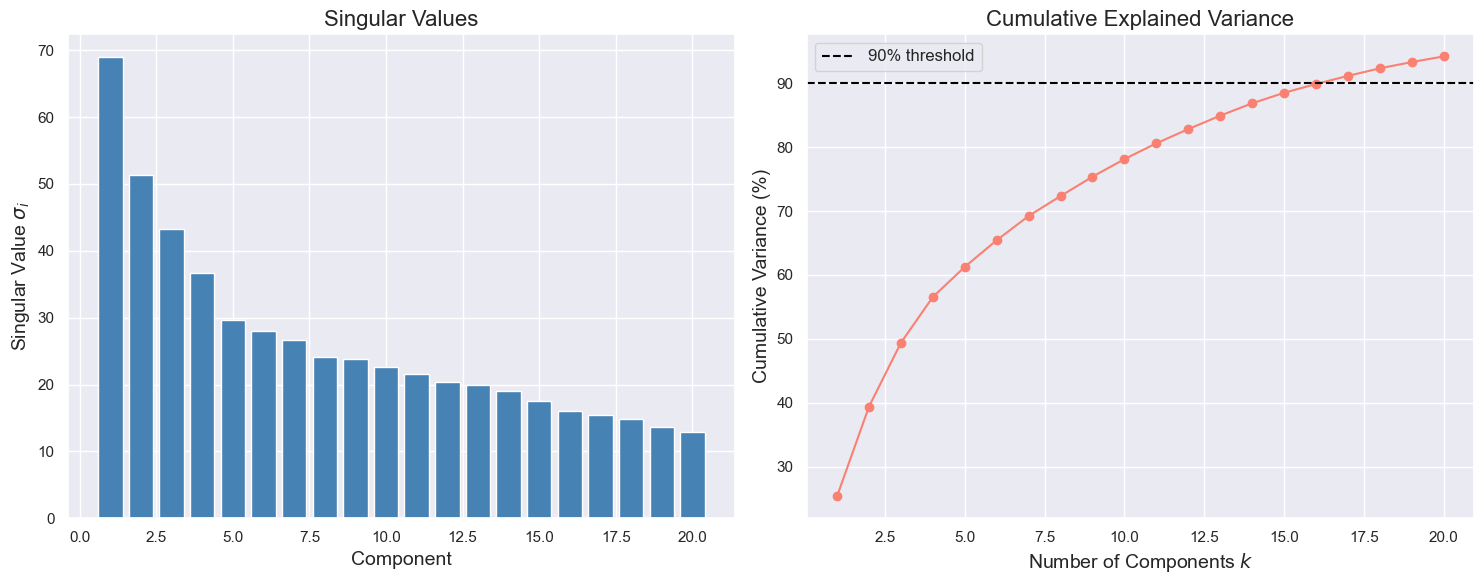

In [6]:
_, s, _ = np.linalg.svd(X_scaled, full_matrices=False)
var_ratio = (s ** 2) / (s ** 2).sum()
cumulative = np.cumsum(var_ratio)

n_show = min(20, len(s))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

ax1.bar(range(1, n_show + 1), s[:n_show], color='steelblue')
ax1.set_xlabel('Component', fontsize=14)
ax1.set_ylabel('Singular Value $\sigma_i$', fontsize=14)
ax1.set_title('Singular Values', fontsize=16)

ax2.plot(range(1, n_show + 1), cumulative[:n_show] * 100, marker='o', color='salmon')
ax2.axhline(90, color='black', linestyle='--', label='90% threshold')
ax2.set_xlabel('Number of Components $k$', fontsize=14)
ax2.set_ylabel('Cumulative Variance (%)', fontsize=14)
ax2.set_title('Cumulative Explained Variance', fontsize=16)
ax2.legend(fontsize=12)

plt.tight_layout()
plt.show()

Explained variance ratio (k=2): 0.394


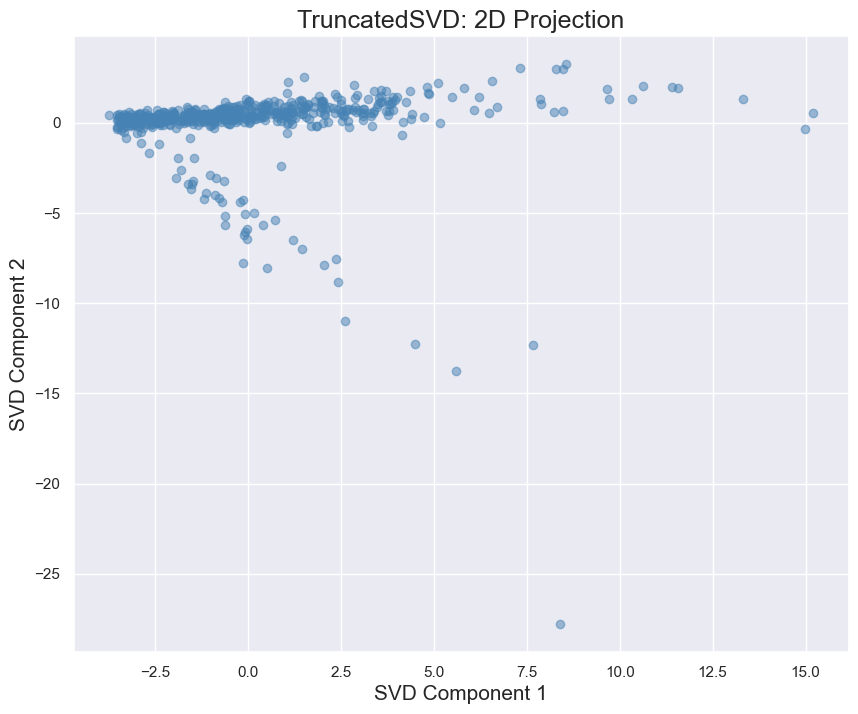

In [7]:
# Project to 2D with TruncatedSVD
svd = TruncatedSVD(n_components=2)
X_proj = svd.fit_transform(X_scaled)

print(f'Explained variance ratio (k=2): {svd.explained_variance_ratio_.sum():.3f}')

plt.figure(figsize=(10, 8))
plt.scatter(X_proj[:, 0], X_proj[:, 1], alpha=0.5, color='steelblue')
plt.xlabel('SVD Component 1', fontsize=15)
plt.ylabel('SVD Component 2', fontsize=15)
plt.title('TruncatedSVD: 2D Projection', fontsize=18)
plt.show()

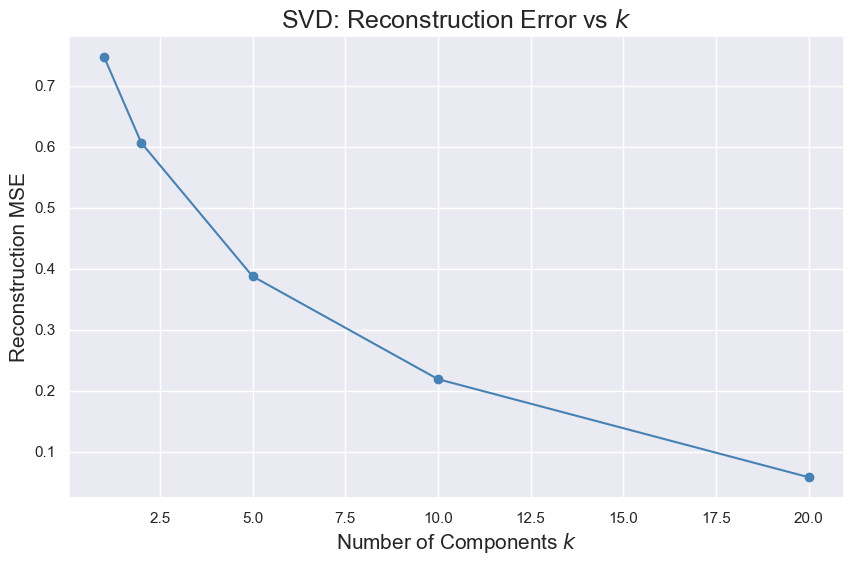

In [8]:
# Low-rank reconstruction quality
k_values = [1, 2, 5, 10, 20]
errors = []

for k in k_values:
    if k >= min(X_scaled.shape):
        break
    svd_k = TruncatedSVD(n_components=k)
    X_reduced = svd_k.fit_transform(X_scaled)
    X_recon = svd_k.inverse_transform(X_reduced)
    errors.append(np.mean((X_scaled - X_recon) ** 2))

plt.figure(figsize=(10, 6))
plt.plot(k_values[:len(errors)], errors, marker='o', color='steelblue')
plt.xlabel('Number of Components $k$', fontsize=15)
plt.ylabel('Reconstruction MSE', fontsize=15)
plt.title('SVD: Reconstruction Error vs $k$', fontsize=18)
plt.show()

## Interpretation

- The **singular values** $\sigma_i$ decay rapidly: the first few components capture most of the information. this rapid decay confirms the data has low intrinsic rank.
- SVD gives the **best rank-$k$ approximation** in the Frobenius norm sense (Eckart-Young theorem). no other rank-$k$ matrix is closer to the original.
- For food data, the top SVD components correspond to macro-nutrient axes: the first component likely captures caloric density (high fat + high carb vs low-calorie), while the second may separate protein-dense foods from carbohydrate-dense foods.
- The **reconstruction error vs $k$** plot mirrors the singular value decay: most error reduction happens in the first few components, with diminishing returns after that.
- SVD differs from PCA in that it does not require centering: if your data has a meaningful absolute zero (e.g. pixel intensities, count data), prefer TruncatedSVD over PCA.